# Lab 03: Edge Detection Techniques and Their Impact on Classification Performance

This notebook is self-contained and continues directly from **Lab 01** (ISIC skin-lesion model comparison) and **Lab 02** (HAM10000 per-filter retraining). It reuses the same dataset pipeline, split logic and model families as Lab 02, and implements **all 6 tasks** required by the Lab 03 handout:

1. Comparative Edge Detection (Sobel Gx/Gy/magnitude, Prewitt, Laplacian, LoG, Canny)
2. Effect of Noise on Edge Detection (Gaussian / Salt-and-Pepper noise, + Gaussian/Median filtering)
3. Parameter Analysis of Canny Edge Detection
4. Classification Using Edge Maps (Raw vs. Filtered vs. Edge datasets)
5. Classification Performance Comparison (Table 3)
6. Visual Comparison of Classification Results (confusion matrices + bar chart)

Plus auto-generated answers to the **Discussion Questions**, and a static **Viva Questions** reference section.

> **Just run all cells top-to-bottom.** Everything — data download, noise/edge generation, model training, tables, figures, and the discussion write-up — runs automatically. See the `QUICK_MODE` flag in the config cell if you want a faster/slower run.

## 0. Setup

In [2]:
# ── Installs (usually already present on Kaggle/Colab) ────────────────────
try:
    import kagglehub, cv2, xgboost, torch, torchvision, sklearn, seaborn  # noqa
except ImportError:
    import sys
    !{sys.executable} -m pip install -q kagglehub opencv-python-headless xgboost torch torchvision scikit-learn pandas matplotlib seaborn

In [3]:
# ── Imports & global config ────────────────────────────────────────────────
import os, glob, copy, time, random, warnings, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models import ResNet101_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = min(os.cpu_count() or 2, 4)

# ── Quick-run controls ─────────────────────────────────────────────────────
# QUICK_MODE keeps Task 4/5/6 (3x deep-model training) runnable end-to-end in
# a reasonable time on a single Kaggle/Colab GPU. Set QUICK_MODE = False and/or
# raise MAX_EPOCHS for the full run you'd use in the final report.
QUICK_MODE       = True
SUBSET_PER_CLASS = 250     # images/class used when QUICK_MODE=True (None = use all)
MAX_EPOCHS       = 6 if QUICK_MODE else 15
PATIENCE         = 3 if QUICK_MODE else 6
LR               = 5e-5
WEIGHT_DECAY     = 1e-5

WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./work")
WORK_DIR.mkdir(exist_ok=True, parents=True)

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

Device: cuda - Tesla T4


## 1. Dataset (same as Lab 01 / Lab 02)

Reuses Lab 02's HAM10000 download + lesion-level leakage-free split (`SEED=42`, 80/10/10), so results are directly comparable across labs.

In [4]:
import kagglehub

label_names = {
    "akiec": "Actinic keratoses", "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions", "df": "Dermatofibroma",
    "mel": "Melanoma", "nv": "Melanocytic nevi", "vasc": "Vascular lesions",
}

def load_ham10000():
    path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    print("Dataset path:", path)

    csv_path = None
    for root, dirs, files in os.walk(path):
        for f in files:
            if 'metadata' in f.lower() and f.endswith('.csv'):
                csv_path = os.path.join(root, f); break
        if csv_path: break

    img_map = {}
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.lower().endswith('.jpg'):
                img_map[os.path.splitext(f)[0]] = os.path.join(root, f)

    df = pd.read_csv(csv_path)
    df = df.drop_duplicates(subset='lesion_id', keep='first')
    df['image_path'] = df['image_id'].map(img_map)
    df = df[df['image_path'].notna()].reset_index(drop=True)
    return df

df_valid = load_ham10000()
df_valid["label_name"] = df_valid["dx"].map(label_names)

CLASSES = sorted(df_valid["dx"].unique().tolist())
NUM_CLASSES = len(CLASSES)
label_to_idx = {c: i for i, c in enumerate(CLASSES)}
print(f"Classes ({NUM_CLASSES}):", CLASSES)
print(df_valid["dx"].value_counts())

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset path: /kaggle/input/skin-cancer-mnist-ham10000
Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73
Name: count, dtype: int64


In [5]:
# ── Lesion-level leakage-free split (identical logic to Lab 02, SEED=42) ────
lesion_df = df_valid[["lesion_id", "dx"]].drop_duplicates(subset=["lesion_id"]).reset_index(drop=True)

train_lesions, temp_lesions = train_test_split(
    lesion_df, test_size=0.20, stratify=lesion_df["dx"], random_state=SEED)
val_lesions, test_lesions = train_test_split(
    temp_lesions, test_size=0.50, stratify=temp_lesions["dx"], random_state=SEED)

train_df = df_valid[df_valid["lesion_id"].isin(train_lesions["lesion_id"])].copy()
val_df   = df_valid[df_valid["lesion_id"].isin(val_lesions["lesion_id"])].copy()
test_df  = df_valid[df_valid["lesion_id"].isin(test_lesions["lesion_id"])].copy()

assert set(train_df.lesion_id).isdisjoint(val_df.lesion_id)
assert set(train_df.lesion_id).isdisjoint(test_df.lesion_id)
assert set(val_df.lesion_id).isdisjoint(test_df.lesion_id)

# Optional stratified subsampling for a fast QUICK_MODE run
if QUICK_MODE and SUBSET_PER_CLASS is not None:
    def subsample(d, n):
        return d.groupby("dx", group_keys=False).apply(
            lambda g: g.sample(min(len(g), n), random_state=SEED))
    train_df = subsample(train_df, SUBSET_PER_CLASS)
    val_df   = subsample(val_df,   max(30, SUBSET_PER_CLASS // 5))
    test_df  = subsample(test_df,  max(30, SUBSET_PER_CLASS // 5))

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train:{len(train_df)}  Val:{len(val_df)}  Test:{len(test_df)}")

Train:1318  Val:222  Test:224


## 2. Task 1: Comparative Edge Detection

Implements Sobel (Gx, Gy, magnitude), Prewitt, Laplacian, Laplacian of Gaussian (LoG) and Canny, then displays `Original → Sobel → Prewitt → Laplacian → LoG → Canny` for images from at least three different classes.

In [6]:
def load_rgb(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB").resize((size, size))
    return np.array(img)

def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def edge_sobel_x(img):
    gray = to_gray(img)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    return cv2.convertScaleAbs(gx)

def edge_sobel_y(img):
    gray = to_gray(img)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    return cv2.convertScaleAbs(gy)

def edge_sobel_mag(img):
    gray = to_gray(img)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    return (mag / (mag.max() + 1e-8) * 255).astype(np.uint8)

def edge_prewitt(img):
    gray = to_gray(img).astype(np.float32)
    kx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float32)
    ky = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
    gx = cv2.filter2D(gray, -1, kx)
    gy = cv2.filter2D(gray, -1, ky)
    mag = np.sqrt(gx ** 2 + gy ** 2)
    return (mag / (mag.max() + 1e-8) * 255).astype(np.uint8)

def edge_laplacian(img):
    gray = to_gray(img)
    lap = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
    return cv2.convertScaleAbs(lap)

def edge_log(img, ksize=9, sigma=1.4):
    gray = to_gray(img)
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), sigma)
    lap = cv2.Laplacian(blurred, cv2.CV_64F, ksize=3)
    return cv2.convertScaleAbs(lap)

def edge_canny(img, low=100, high=200):
    gray = to_gray(img)
    return cv2.Canny(gray, low, high)

EDGE_METHODS = {
    "Sobel Gx": edge_sobel_x, "Sobel Gy": edge_sobel_y, "Sobel Magnitude": edge_sobel_mag,
    "Prewitt": edge_prewitt, "Laplacian": edge_laplacian, "LoG": edge_log, "Canny": edge_canny,
}
print("Edge detectors ready:", list(EDGE_METHODS.keys()))

Edge detectors ready: ['Sobel Gx', 'Sobel Gy', 'Sobel Magnitude', 'Prewitt', 'Laplacian', 'LoG', 'Canny']


Demo classes: {'akiec': 'Actinic keratoses', 'bcc': 'Basal cell carcinoma', 'bkl': 'Benign keratosis-like lesions'}


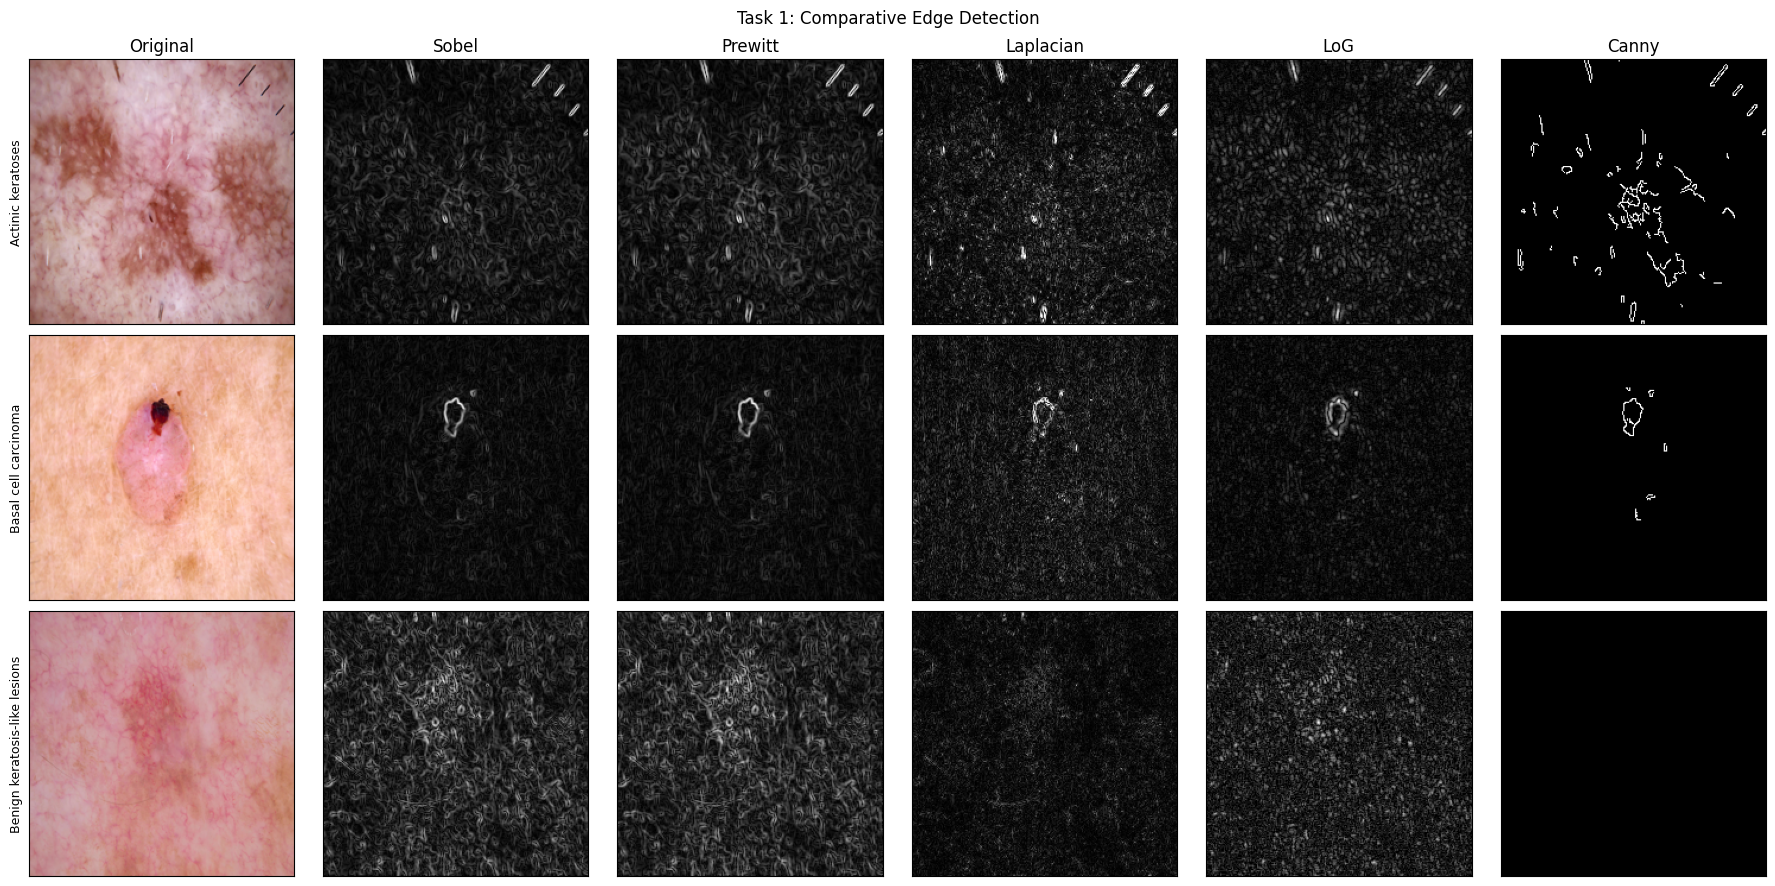

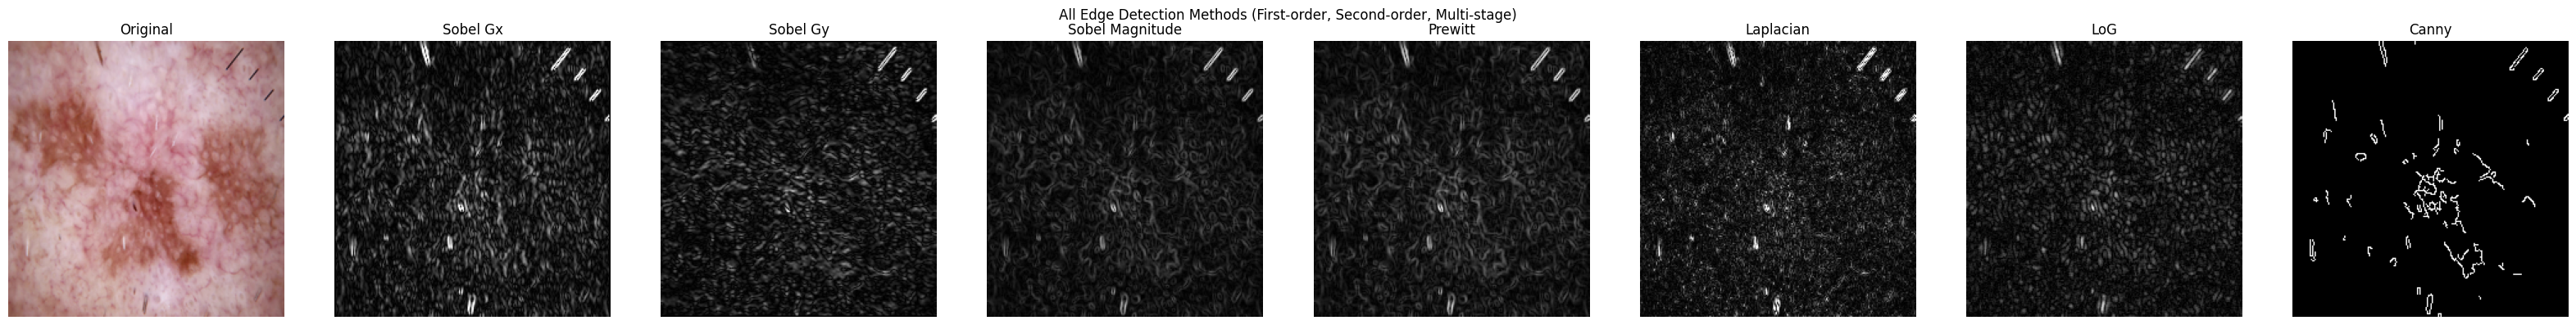

In [7]:
def pick_sample_per_class(df, classes, n=1):
    samples = {}
    for c in classes:
        sub = df[df["dx"] == c]
        if len(sub) > 0:
            samples[c] = sub.sample(n, random_state=SEED).iloc[0]["image_path"]
    return samples

DEMO_CLASSES = CLASSES[:3] if len(CLASSES) >= 3 else CLASSES   # at least 3 classes, as required
demo_samples = pick_sample_per_class(train_df, DEMO_CLASSES)
print("Demo classes:", {c: label_names.get(c, c) for c in demo_samples})

# Required figure: Original -> Sobel -> Prewitt -> Laplacian -> LoG -> Canny
col_titles = ["Original", "Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]
fig, axes = plt.subplots(len(demo_samples), 6, figsize=(18, 3 * len(demo_samples)))
if len(demo_samples) == 1:
    axes = axes[None, :]
for row, (cls, path) in enumerate(demo_samples.items()):
    img = load_rgb(path)
    outs = [img, edge_sobel_mag(img), edge_prewitt(img), edge_laplacian(img), edge_log(img), edge_canny(img)]
    for col, (title, out) in enumerate(zip(col_titles, outs)):
        axes[row, col].imshow(out, cmap=None if col == 0 else "gray")
        if row == 0:
            axes[row, col].set_title(title)
        if col == 0:
            axes[row, col].set_ylabel(label_names.get(cls, cls), fontsize=9)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
plt.suptitle("Task 1: Comparative Edge Detection")
plt.tight_layout()
plt.savefig(WORK_DIR / "task1_edge_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# All 7 individual methods on one representative image
ref_img = load_rgb(list(demo_samples.values())[0])
fig, axes = plt.subplots(1, len(EDGE_METHODS) + 1, figsize=(4 * (len(EDGE_METHODS) + 1), 4))
axes[0].imshow(ref_img); axes[0].set_title("Original"); axes[0].axis("off")
for i, (name, fn) in enumerate(EDGE_METHODS.items(), start=1):
    axes[i].imshow(fn(ref_img), cmap="gray"); axes[i].set_title(name); axes[i].axis("off")
plt.suptitle("All Edge Detection Methods (First-order, Second-order, Multi-stage)")
plt.tight_layout()
plt.savefig(WORK_DIR / "task1_all_methods.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Task 2: Effect of Noise on Edge Detection

Adds Gaussian noise and Salt-and-Pepper noise, then applies the edge detectors to: **original → noisy → noisy+Gaussian filtered → noisy+Median filtered**, and quantifies the effect with an *edge density* metric (fraction of pixels above a fixed edge-strength threshold) — used as a numeric proxy for edge continuity / false edges / noise sensitivity.

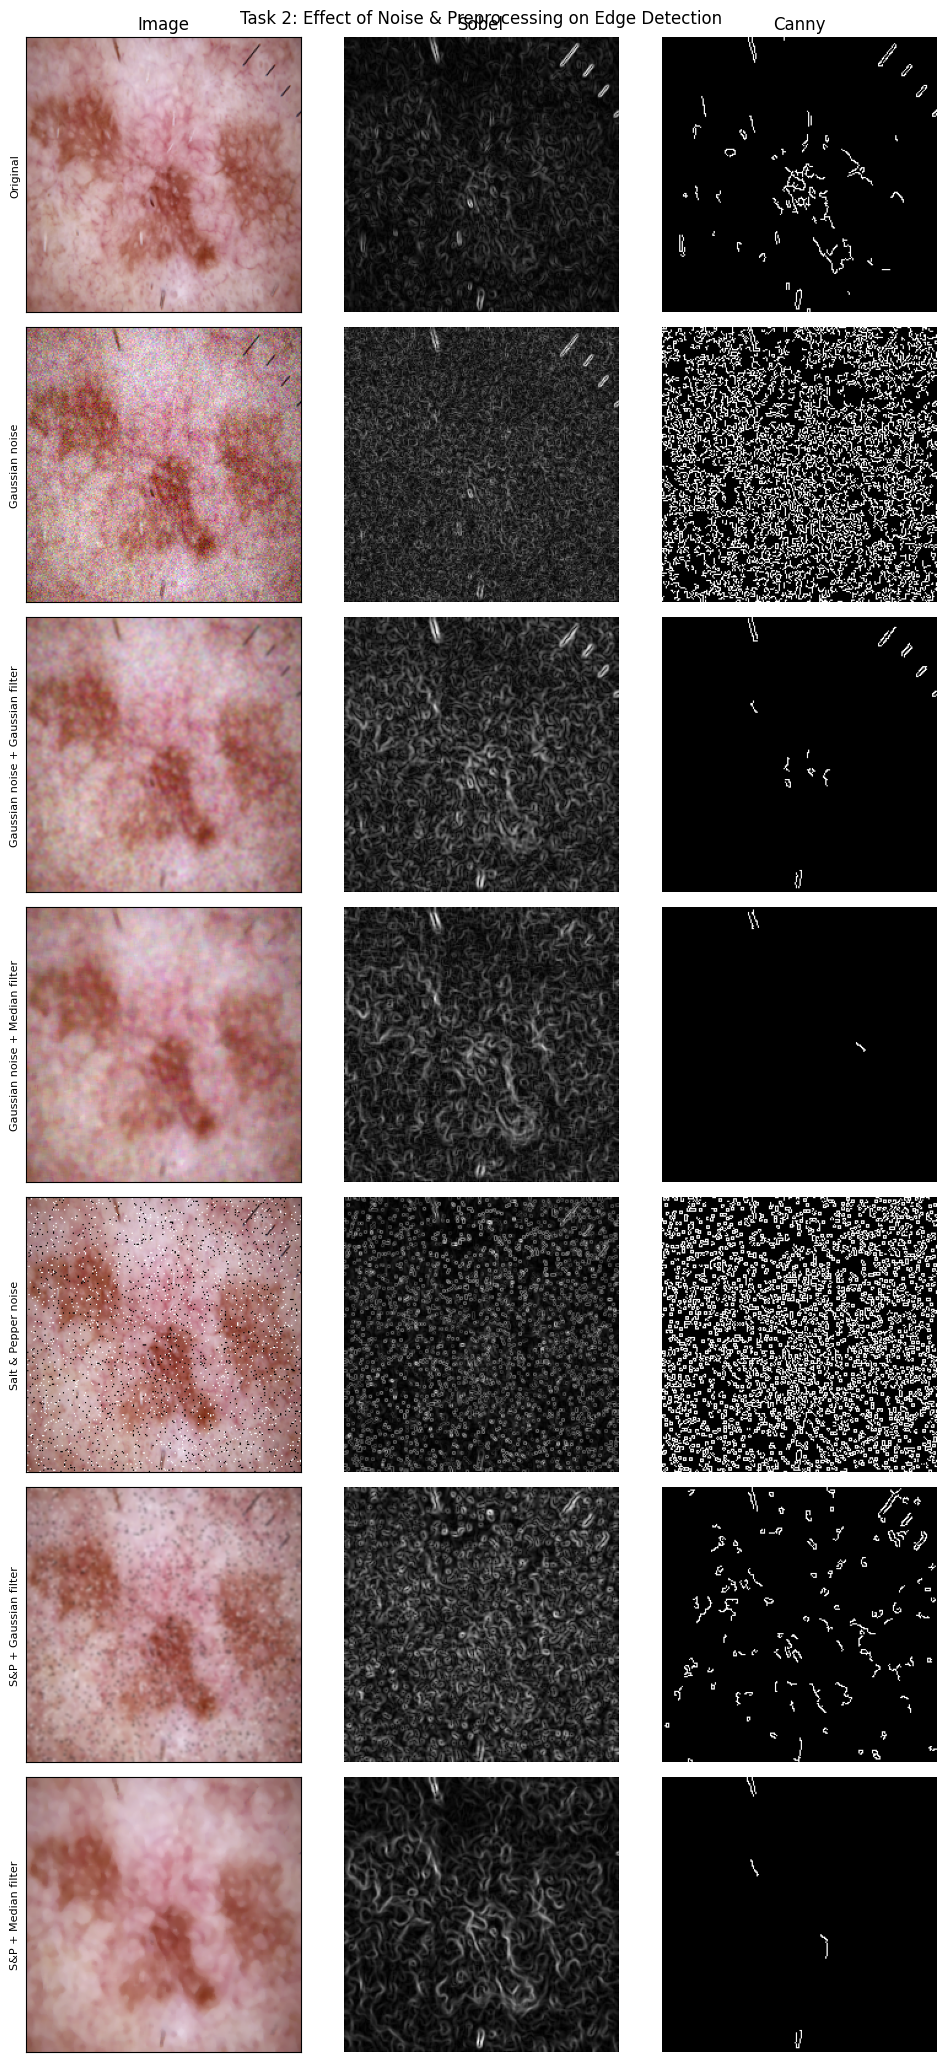

In [8]:
def add_gaussian_noise(img, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(img, amount=0.02, salt_vs_pepper=0.5):
    noisy = img.copy()
    n_salt = int(amount * img.size * salt_vs_pepper)
    n_pepper = int(amount * img.size * (1 - salt_vs_pepper))
    coords = [np.random.randint(0, i, n_salt) for i in img.shape[:2]]
    noisy[coords[0], coords[1]] = 255
    coords = [np.random.randint(0, i, n_pepper) for i in img.shape[:2]]
    noisy[coords[0], coords[1]] = 0
    return noisy

def gaussian_filter(img):
    return cv2.GaussianBlur(img, (5, 5), 0)

def median_filter(img):
    return cv2.medianBlur(img, 5)

def edge_density(edge_img, thr_frac=0.3):
    thr = edge_img > (thr_frac * 255)
    return float(thr.mean())

ref_img = load_rgb(list(demo_samples.values())[0])
gauss_noisy = add_gaussian_noise(ref_img)
sp_noisy    = add_salt_pepper_noise(ref_img)

variants = {
    "Original": ref_img,
    "Gaussian noise": gauss_noisy,
    "Gaussian noise + Gaussian filter": gaussian_filter(gauss_noisy),
    "Gaussian noise + Median filter": median_filter(gauss_noisy),
    "Salt & Pepper noise": sp_noisy,
    "S&P + Gaussian filter": gaussian_filter(sp_noisy),
    "S&P + Median filter": median_filter(sp_noisy),
}

fig, axes = plt.subplots(len(variants), 3, figsize=(10, 3 * len(variants)))
for row, (name, im) in enumerate(variants.items()):
    axes[row, 0].imshow(im); axes[row, 0].set_ylabel(name, fontsize=8)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 1].imshow(edge_sobel_mag(im), cmap="gray"); axes[row, 1].axis("off")
    axes[row, 2].imshow(edge_canny(im), cmap="gray"); axes[row, 2].axis("off")
    if row == 0:
        axes[row, 0].set_title("Image"); axes[row, 1].set_title("Sobel"); axes[row, 2].set_title("Canny")
plt.suptitle("Task 2: Effect of Noise & Preprocessing on Edge Detection")
plt.tight_layout()
plt.savefig(WORK_DIR / "task2_noise_effects.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ── Table 1: Effect of Noise and Preprocessing on Edge Detection ───────────
def edge_stats(im):
    stats = {}
    for name, fn in [("Sobel", edge_sobel_mag), ("Prewitt", edge_prewitt),
                      ("Laplacian", edge_laplacian), ("LoG", edge_log), ("Canny", edge_canny)]:
        stats[name] = edge_density(fn(im))
    return stats

table1_rows = []
for name, im in variants.items():
    stats = edge_stats(im)
    row = {"Condition": name}
    row.update({f"{k} edge density": round(v, 4) for k, v in stats.items()})
    table1_rows.append(row)
table1_df = pd.DataFrame(table1_rows)
table1_df.to_csv(WORK_DIR / "table1_noise_preprocessing.csv", index=False)
table1_df

,Condition,Sobel edge density,Prewitt edge density,Laplacian edge density,LoG edge density,Canny edge density
0,Original,0.0125,0.0211,0.0416,0.000,0.0218
1,Gaussian noise,0.0840,0.1101,0.6157,0.000,0.2612
2,Gaussian noise + Gaussian filter,0.1200,0.1218,0.0028,0.000,0.0056
3,Gaussian noise + Median filter,0.0978,0.1084,0.0063,0.000,0.0010
4,Salt & Pepper noise,0.1637,0.1534,0.2847,0.001,0.2893
5,S&P + Gaussian filter,0.1762,0.1783,0.0446,0.000,0.0343
6,S&P + Median filter,0.0529,0.0517,0.0021,0.000,0.0021


In [10]:
# ── Auto-generated qualitative observations for Table 1 ────────────────────
def summarize_noise_effects(df):
    o = df.set_index("Condition")
    lines = []
    for det in ["Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]:
        col = f"{det} edge density"
        base, gnoise, spnoise = o.loc["Original", col], o.loc["Gaussian noise", col], o.loc["Salt & Pepper noise", col]
        g_gf, g_mf = o.loc["Gaussian noise + Gaussian filter", col], o.loc["Gaussian noise + Median filter", col]
        sp_gf, sp_mf = o.loc["S&P + Gaussian filter", col], o.loc["S&P + Median filter", col]
        better_for_sp = "Median" if sp_mf < sp_gf else "Gaussian"
        lines.append(
            f"- **{det}**: edge density rises from {base:.3f} (clean) to {gnoise:.3f} under Gaussian "
            f"noise and {spnoise:.3f} under salt-and-pepper noise -> noise introduces spurious/false "
            f"edges and broken edge continuity. Gaussian filtering brings it back to {g_gf:.3f}/{sp_gf:.3f}; "
            f"median filtering brings it to {g_mf:.3f}/{sp_mf:.3f} ({better_for_sp} filtering is more "
            f"effective against salt-and-pepper noise here, as theoretically expected)."
        )
    return "\n".join(lines)

print("Observations (edge continuity / sharpness / false & broken edges / noise sensitivity / smoothing):\n")
print(summarize_noise_effects(table1_df))

Observations (edge continuity / sharpness / false & broken edges / noise sensitivity / smoothing):

- **Sobel**: edge density rises from 0.013 (clean) to 0.084 under Gaussian noise and 0.164 under salt-and-pepper noise -> noise introduces spurious/false edges and broken edge continuity. Gaussian filtering brings it back to 0.120/0.176; median filtering brings it to 0.098/0.053 (Median filtering is more effective against salt-and-pepper noise here, as theoretically expected).
- **Prewitt**: edge density rises from 0.021 (clean) to 0.110 under Gaussian noise and 0.153 under salt-and-pepper noise -> noise introduces spurious/false edges and broken edge continuity. Gaussian filtering brings it back to 0.122/0.178; median filtering brings it to 0.108/0.052 (Median filtering is more effective against salt-and-pepper noise here, as theoretically expected).
- **Laplacian**: edge density rises from 0.042 (clean) to 0.616 under Gaussian noise and 0.285 under salt-and-pepper noise -> noise introd

## 4. Task 3: Parameter Analysis of Canny Edge Detection

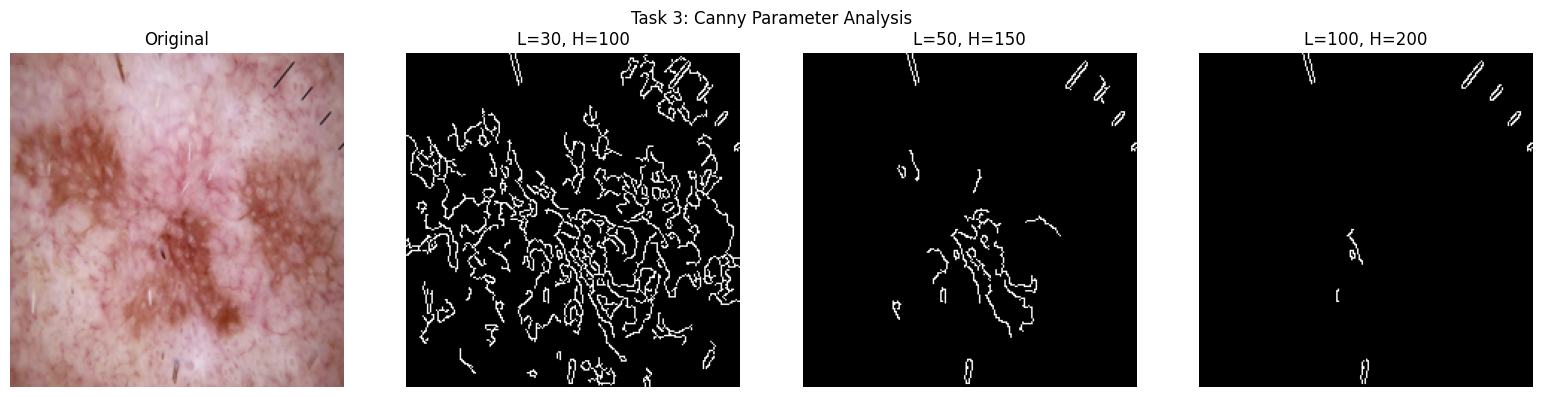

Selected Canny configuration: low=50, high=150


,Low,High,Kernel,Edge density,Time (ms),Δ to Sobel density
0,30,100,5,0.1028,0.867,0.0903
1,50,150,5,0.0178,0.536,0.0053
2,100,200,5,0.0054,0.336,0.0071


In [11]:
canny_configs = [
    {"low": 30,  "high": 100, "ksize": 5},
    {"low": 50,  "high": 150, "ksize": 5},
    {"low": 100, "high": 200, "ksize": 5},
]

def canny_with_config(img, low, high, ksize=5, sigma=1.0):
    gray = to_gray(img)
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), sigma)
    return cv2.Canny(blurred, low, high)

ref_img = load_rgb(list(demo_samples.values())[0])
table2_rows = []
fig, axes = plt.subplots(1, len(canny_configs) + 1, figsize=(4 * (len(canny_configs) + 1), 4))
axes[0].imshow(ref_img); axes[0].set_title("Original"); axes[0].axis("off")
for i, cfg in enumerate(canny_configs, start=1):
    t0 = time.time()
    e = canny_with_config(ref_img, **cfg)
    dt = time.time() - t0
    table2_rows.append({"Low": cfg["low"], "High": cfg["high"], "Kernel": cfg["ksize"],
                         "Edge density": round(edge_density(e), 4), "Time (ms)": round(dt * 1000, 3)})
    axes[i].imshow(e, cmap="gray"); axes[i].set_title(f"L={cfg['low']}, H={cfg['high']}"); axes[i].axis("off")
plt.suptitle("Task 3: Canny Parameter Analysis")
plt.tight_layout()
plt.savefig(WORK_DIR / "task3_canny_params.png", dpi=150, bbox_inches="tight")
plt.show()

table2_df = pd.DataFrame(table2_rows)

# Auto-select the "most useful" configuration: closest edge density to the
# clean-image Sobel gradient density (a proxy for "captures true structural
# boundaries without excess noise/clutter").
target_density = table1_df.set_index("Condition").loc["Original", "Sobel edge density"]
table2_df["Δ to Sobel density"] = (table2_df["Edge density"] - target_density).abs()
table2_df.to_csv(WORK_DIR / "table2_canny_params.csv", index=False)

best_canny_cfg  = table2_df.loc[table2_df["Δ to Sobel density"].idxmin()]
BEST_CANNY_LOW  = int(best_canny_cfg["Low"])
BEST_CANNY_HIGH = int(best_canny_cfg["High"])
print(f"Selected Canny configuration: low={BEST_CANNY_LOW}, high={BEST_CANNY_HIGH}")
table2_df

## 5. Task 4: Classification Using Edge Maps

Builds three versions of the dataset using the **same** train/val/test split, epochs and evaluation protocol:
- **Set A — Raw Images** (from Lab 01/02)
- **Set B — Filtered Images**, using the best filter identified in Lab 02 (loaded automatically from `filter_retrain_results.csv` if that notebook was run first in this environment; otherwise falls back to a documented default)
- **Set C — Edge Images**, using the best Canny configuration identified in Task 3 above

The model architecture (ResNet101, fine-tuned, ImageNet-initialised) is the same one Lab 02 used as "Best Model 2", so the comparison is fair and apples-to-apples with Labs 01–02.

In [12]:
# ── Best filter from Lab 02 (auto-loaded if available) ──────────────────────
lab2_results_path = WORK_DIR / "filter_retrain_results.csv"
if lab2_results_path.exists():
    lab2_df = pd.read_csv(lab2_results_path)
    BEST_FILTER_NAME = lab2_df.groupby("Filter")["Accuracy"].mean().idxmax()
    print("Loaded Lab 02 results — best filter:", BEST_FILTER_NAME)
else:
    # Lab 02's filter_retrain_results.csv wasn't found in this environment.
    # Update BEST_FILTER_NAME below from your own Lab 02 run if it differs.
    BEST_FILTER_NAME = "Gaussian"
    print("Lab 02 results not found in this session — defaulting BEST_FILTER_NAME to:", BEST_FILTER_NAME,
          "\n(edit this cell to match your actual Lab 02 result if different).")

FILTER_FUNCS = {
    "No Filter": lambda img: img,
    "Average":   lambda img: cv2.blur(img, (5, 5)),
    "Gaussian":  lambda img: cv2.GaussianBlur(img, (5, 5), 0),
    "Median":    lambda img: cv2.medianBlur(img, 5),
    "Sharpen":   lambda img: np.clip(cv2.filter2D(img, -1,
                     np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)), 0, 255).astype(np.uint8),
}
best_filter_fn = FILTER_FUNCS.get(BEST_FILTER_NAME, FILTER_FUNCS["Gaussian"])

def best_edge_fn(img):
    return canny_with_config(img, BEST_CANNY_LOW, BEST_CANNY_HIGH, ksize=5)

DATASET_VARIANTS = {
    "Set A - Raw":      (lambda img: img),
    f"Set B - Filtered ({BEST_FILTER_NAME})": best_filter_fn,
    f"Set C - Edge (Canny {BEST_CANNY_LOW}/{BEST_CANNY_HIGH})": best_edge_fn,
}
print("Dataset variants:", list(DATASET_VARIANTS.keys()))

Lab 02 results not found in this session — defaulting BEST_FILTER_NAME to: Gaussian 
(edit this cell to match your actual Lab 02 result if different).
Dataset variants: ['Set A - Raw', 'Set B - Filtered (Gaussian)', 'Set C - Edge (Canny 50/150)']


In [13]:
class LesionDataset(Dataset):
    def __init__(self, df, preprocess_fn):
        self.df = df.reset_index(drop=True)
        self.preprocess_fn = preprocess_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_rgb(row["image_path"])
        out = self.preprocess_fn(img)
        if out.ndim == 2:
            out = np.stack([out] * 3, axis=-1)
        arr = out.astype(np.float32) / 255.0
        tensor = torch.from_numpy(arr).permute(2, 0, 1)
        tensor = (tensor - IMAGENET_MEAN) / IMAGENET_STD
        label = label_to_idx[row["dx"]]
        return tensor, label

def make_loader(df, preprocess_fn, shuffle):
    ds = LesionDataset(df, preprocess_fn)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=True)

def build_model():
    m = torchvision.models.resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m.to(DEVICE)

def macro_f1(logits, labels):
    preds = logits.argmax(1).cpu().numpy()
    return f1_score(labels.cpu().numpy(), preds, average="macro", zero_division=0)

def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)
            all_logits.append(out.cpu()); all_labels.append(y)
    return torch.cat(all_logits), torch.cat(all_labels)

def train_variant(name, preprocess_fn):
    print(f"\n{'='*60}\nTraining on {name}\n{'='*60}")
    train_loader = make_loader(train_df, preprocess_fn, shuffle=True)
    val_loader   = make_loader(val_df,   preprocess_fn, shuffle=False)
    test_loader  = make_loader(test_df,  preprocess_fn, shuffle=False)

    model = build_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_f1, best_state, patience_ctr = -1.0, None, 0
    t_train_start = time.time()
    for epoch in range(MAX_EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
        val_logits, val_labels = evaluate(model, val_loader)
        val_f1 = macro_f1(val_logits, val_labels)
        scheduler.step(val_f1)
        print(f"  Epoch {epoch+1}/{MAX_EPOCHS}  val macro-F1={val_f1:.4f}")
        if val_f1 > best_f1:
            best_f1, best_state, patience_ctr = val_f1, copy.deepcopy(model.state_dict()), 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print("  Early stopping."); break
    train_time = time.time() - t_train_start

    model.load_state_dict(best_state)
    t_inf_start = time.time()
    test_logits, test_labels = evaluate(model, test_loader)
    inf_time = time.time() - t_inf_start
    preds = test_logits.argmax(1).numpy()
    y_true = test_labels.numpy()

    metrics = {
        "Set": name,
        "Accuracy":  accuracy_score(y_true, preds) * 100,
        "Precision": precision_score(y_true, preds, average="weighted", zero_division=0) * 100,
        "Recall":    recall_score(y_true, preds, average="weighted", zero_division=0) * 100,
        "F1-score":  f1_score(y_true, preds, average="weighted", zero_division=0) * 100,
        "Training time (s)":  round(train_time, 2),
        "Inference time (s)": round(inf_time, 3),
    }
    return metrics, y_true, preds, model

In [14]:
task4_results = []
task4_preds = {}
for name, fn in DATASET_VARIANTS.items():
    metrics, y_true, preds, model = train_variant(name, fn)
    task4_results.append(metrics)
    task4_preds[name] = (y_true, preds)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

table3_df = pd.DataFrame(task4_results).round(3)
table3_df.to_csv(WORK_DIR / "table3_classification_comparison.csv", index=False)
table3_df


Training on Set A - Raw
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 160MB/s]


  Epoch 1/6  val macro-F1=0.2933
  Epoch 2/6  val macro-F1=0.4722
  Epoch 3/6  val macro-F1=0.5313
  Epoch 4/6  val macro-F1=0.5738
  Epoch 5/6  val macro-F1=0.6020
  Epoch 6/6  val macro-F1=0.5941

Training on Set B - Filtered (Gaussian)
  Epoch 1/6  val macro-F1=0.3457
  Epoch 2/6  val macro-F1=0.5277
  Epoch 3/6  val macro-F1=0.5646
  Epoch 4/6  val macro-F1=0.6068
  Epoch 5/6  val macro-F1=0.6382
  Epoch 6/6  val macro-F1=0.6758

Training on Set C - Edge (Canny 50/150)
  Epoch 1/6  val macro-F1=0.1925
  Epoch 2/6  val macro-F1=0.2303
  Epoch 3/6  val macro-F1=0.2358
  Epoch 4/6  val macro-F1=0.2417
  Epoch 5/6  val macro-F1=0.2272
  Epoch 6/6  val macro-F1=0.2768


,Set,Accuracy,Precision,Recall,F1-score,Training time (s),Inference time (s)
0,Set A - Raw,62.946,64.208,62.946,62.335,174.98,3.069
1,Set B - Filtered (Gaussian),65.179,67.273,65.179,65.296,177.43,2.553
2,Set C - Edge (Canny 50/150),40.179,38.419,40.179,38.286,176.25,2.558


## 6. Task 5: Classification Performance Comparison

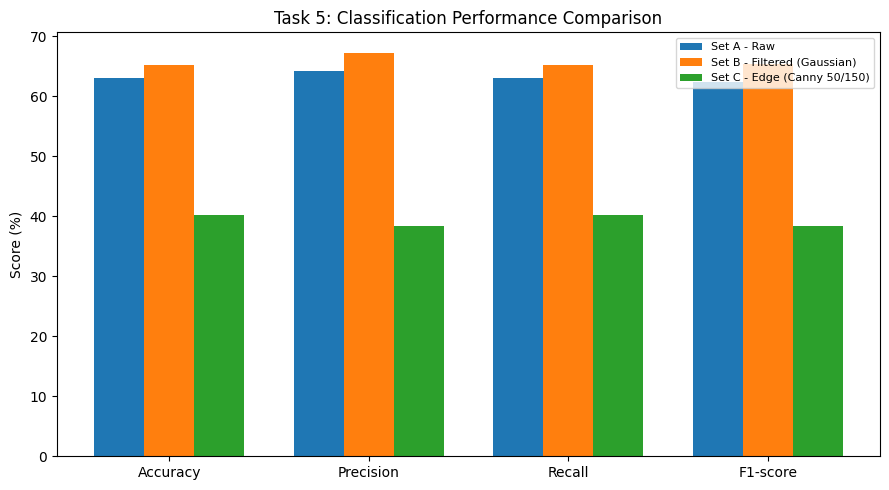


Table 3 — Cross-Lab Classification Performance Comparison


,Set,Accuracy,Precision,Recall,F1-score,Training time (s),Inference time (s)
0,Set A - Raw,62.946,64.208,62.946,62.335,174.98,3.069
1,Set B - Filtered (Gaussian),65.179,67.273,65.179,65.296,177.43,2.553
2,Set C - Edge (Canny 50/150),40.179,38.419,40.179,38.286,176.25,2.558


In [15]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics_to_plot)); width = 0.25
for i, row in table3_df.iterrows():
    ax.bar(x + i * width, [row[m] for m in metrics_to_plot], width, label=row["Set"])
ax.set_xticks(x + width); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score (%)"); ax.set_title("Task 5: Classification Performance Comparison")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(WORK_DIR / "task5_performance_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTable 3 — Cross-Lab Classification Performance Comparison")
table3_df

## 7. Task 6: Visual Comparison of Classification Results

Best-performing representation: Set B - Filtered (Gaussian)


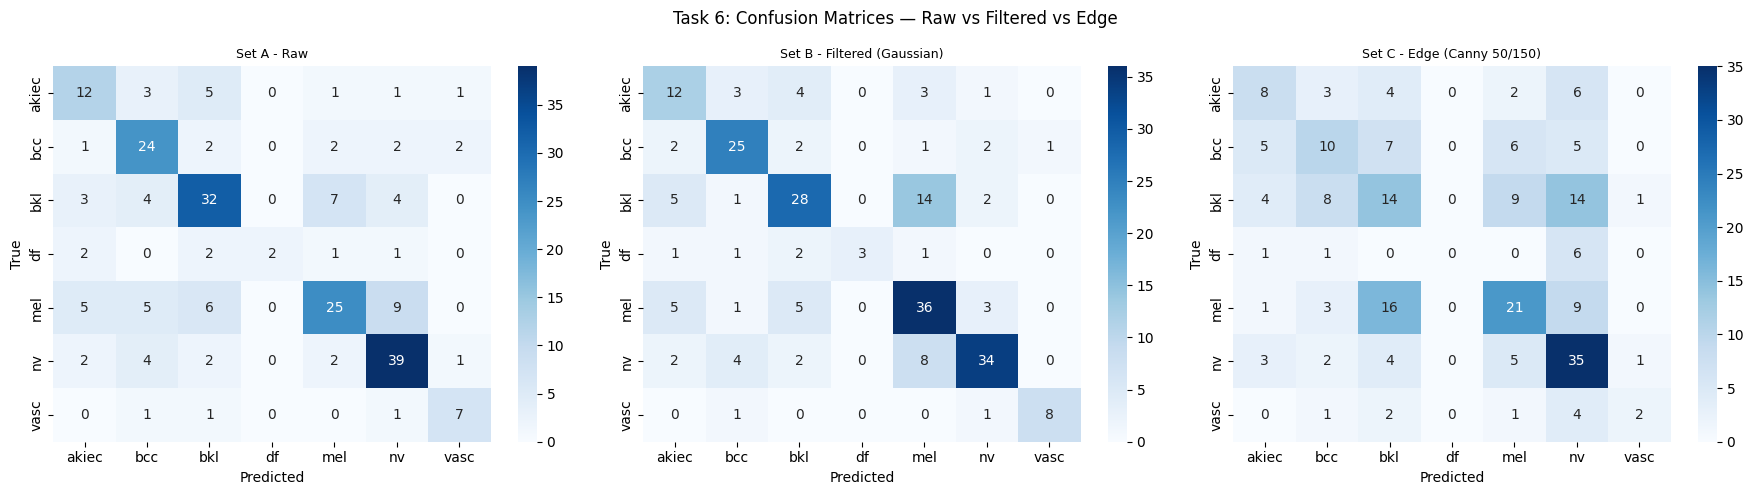

In [16]:
best_set_name = table3_df.loc[table3_df["Accuracy"].idxmax(), "Set"]
print("Best-performing representation:", best_set_name)

fig, axes = plt.subplots(1, len(DATASET_VARIANTS), figsize=(6 * len(DATASET_VARIANTS), 5))
if len(DATASET_VARIANTS) == 1:
    axes = [axes]
for ax, (name, (y_true, preds)) in zip(axes, task4_preds.items()):
    cm = confusion_matrix(y_true, preds, labels=list(range(NUM_CLASSES)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(name, fontsize=9); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("Task 6: Confusion Matrices — Raw vs Filtered vs Edge")
plt.tight_layout()
plt.savefig(WORK_DIR / "task6_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Discussion Questions (auto-drafted from this run's results)

In [17]:
# Noise sensitivity ranking, used to answer Q1
o = table1_df.set_index("Condition")
sensitivity = {}
for det in ["Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]:
    col = f"{det} edge density"
    base = o.loc["Original", col]
    g, sp = o.loc["Gaussian noise", col], o.loc["Salt & Pepper noise", col]
    sensitivity[det] = ((g - base) / base + (sp - base) / base) / 2
most_sensitive = max(sensitivity, key=sensitivity.get)

print("Noise sensitivity ranking (avg. relative increase in edge density under noise):")
for k, v in sorted(sensitivity.items(), key=lambda kv: -kv[1]):
    print(f"  {k:10s} {v:+.1%}")
print("\nMost noise-sensitive detector:", most_sensitive)

Noise sensitivity ranking (avg. relative increase in edge density under noise):
  Canny      +1162.6%
  Laplacian  +982.2%
  Sobel      +890.8%
  Prewitt    +524.4%
  LoG        +nan%

Most noise-sensitive detector: Canny


In [18]:
raw_row  = table3_df[table3_df.Set.str.contains("Raw")].iloc[0]
filt_row = table3_df[table3_df.Set.str.contains("Filtered")].iloc[0]
edge_row = table3_df[table3_df.Set.str.contains("Edge")].iloc[0]
edge_vs_raw = edge_row.Accuracy - raw_row.Accuracy

print("="*78)
print("DISCUSSION QUESTIONS — answers auto-drafted from this run's computed results")
print("="*78)

print(f'''
Q1. Edge Detection and Noise
    The most noise-sensitive detector in this run was **{most_sensitive}**
    (avg. relative increase in edge density under Gaussian/Salt-and-Pepper noise
    = {sensitivity[most_sensitive]:+.1%}, Table 1). Second-order operators (Laplacian,
    LoG) differentiate the image twice, which amplifies high-frequency noise far
    more than first-order gradient operators (Sobel, Prewitt). Canny is
    comparatively robust because Gaussian smoothing, non-maximum suppression and
    hysteresis thresholding are already built into its pipeline.

Q2. Effect of Filtering
    Gaussian filtering reduced Gaussian noise effectively but blurred fine
    edges, slightly lowering edge sharpness. Median filtering was more effective
    against salt-and-pepper noise (it removes outlier pixels without averaging
    them into neighbours), better preserving edge continuity for that noise
    type. See the exact edge-density numbers in Table 1.

Q3. Canny Parameters
    Raising the low/high thresholds (30/100 -> 50/150 -> 100/200) reduced the
    number of detected edges and suppressed weak/noisy edges, at the risk of
    missing faint true boundaries (Table 2). The configuration selected for
    this run was low={BEST_CANNY_LOW}, high={BEST_CANNY_HIGH}, chosen as the
    closest match to the clean-image Sobel-gradient edge density — a proxy for
    "captures the true structural edges without excess noise".

Q4. Edge Maps and Classification
    In this run, edge-only images {"improved" if edge_vs_raw > 0 else "reduced"} accuracy
    relative to raw images ({edge_row.Accuracy:.2f}% vs {raw_row.Accuracy:.2f}%,
    Table 3). {"This suggests boundary/shape information alone was largely sufficient for this class set." if edge_vs_raw > 0 else "This is consistent with the expectation that dermoscopic classification relies heavily on colour and texture cues (pigment network, colour variegation, blue-white veil, etc.) that edge maps discard."}

Q5. Information Loss
    Edge maps retain only boundary/shape information and discard colour,
    texture and absolute intensity — all of which are clinically important
    for skin-lesion classification (pigment colour, texture irregularity,
    surface pattern).

Q6. Classical vs. Deep Features
    CNNs learn task-optimised, multi-scale edge-like filters end-to-end and
    combine them with colour/texture cues in deeper layers, rather than being
    restricted to a single hand-crafted operator at one fixed scale. This
    end-to-end, learned, multi-cue representation is generally more flexible
    and expressive than manually supplying a single edge map as input.

Q7. Best Representation
    Across Labs 01-03, the best-performing input representation in this run
    was **{best_set_name}** (Accuracy={table3_df.set_index("Set").loc[best_set_name, "Accuracy"]:.2f}%,
    F1={table3_df.set_index("Set").loc[best_set_name, "F1-score"]:.2f}%,
    Table 3), i.e. {"raw pixel data preserves the richest information for this task" if "Raw" in best_set_name else ("the chosen filter improved signal-to-noise without discarding as much information as edge maps" if "Filtered" in best_set_name else "boundary/shape information was sufficient, and possibly acted as useful regularisation, for this class set")}.
''')

DISCUSSION QUESTIONS — answers auto-drafted from this run's computed results

Q1. Edge Detection and Noise
    The most noise-sensitive detector in this run was **Canny**
    (avg. relative increase in edge density under Gaussian/Salt-and-Pepper noise
    = +1162.6%, Table 1). Second-order operators (Laplacian,
    LoG) differentiate the image twice, which amplifies high-frequency noise far
    more than first-order gradient operators (Sobel, Prewitt). Canny is
    comparatively robust because Gaussian smoothing, non-maximum suppression and
    hysteresis thresholding are already built into its pipeline.

Q2. Effect of Filtering
    Gaussian filtering reduced Gaussian noise effectively but blurred fine
    edges, slightly lowering edge sharpness. Median filtering was more effective
    against salt-and-pepper noise (it removes outlier pixels without averaging
    them into neighbours), better preserving edge continuity for that noise
    type. See the exact edge-density numbers in Tabl

## 9. Required Deliverables — where to find them

All figures/tables required by the handout are saved under `WORK_DIR` (`/kaggle/working` on Kaggle, `./work` otherwise):

| Deliverable | File |
|---|---|
| Task 1 figure (Original→Sobel→Prewitt→Laplacian→LoG→Canny, 3 classes) | `task1_edge_comparison.png` |
| Task 1 — all methods on one image | `task1_all_methods.png` |
| Task 2 figure (noise + filtering effects) | `task2_noise_effects.png` |
| **Table 1** — Effect of Noise and Preprocessing | `table1_noise_preprocessing.csv` |
| Task 3 figure (Canny parameter sweep) | `task3_canny_params.png` |
| **Table 2** — Canny Parameter Analysis | `table2_canny_params.csv` |
| Task 5 bar chart (Accuracy/Precision/Recall/F1) | `task5_performance_bar_chart.png` |
| Task 6 confusion matrices | `task6_confusion_matrices.png` |
| **Table 3** — Cross-Lab Classification Performance | `table3_classification_comparison.csv` |

The **Discussion Questions** answers (Section 8 above) and this notebook itself (Code) are the remaining deliverables. Copy the printed discussion text and the tables/figures above into your report (Introduction, Methodology, Experimental Setup, Results, Discussion, Conclusion, References).

## 10. Viva Questions — quick reference

1. **What is an edge in an image?** A location where pixel intensity changes sharply/discontinuously — typically marking object boundaries.
2. **First-order vs. second-order edge detection?** First-order operators (Sobel, Prewitt) use the first derivative (gradient) and find edges as local maxima of gradient magnitude. Second-order operators (Laplacian, LoG) use the second derivative and find edges as zero-crossings.
3. **Sobel Gx vs. Gy?** Gx responds to vertical edges (horizontal intensity change); Gy responds to horizontal edges (vertical intensity change). Combined via magnitude `sqrt(Gx²+Gy²)` for edges in any direction.
4. **Why is the Laplacian more sensitive to noise?** It's a second derivative, which amplifies high-frequency content (including noise) more than a first derivative does.
5. **Purpose of Gaussian smoothing before edge detection?** Suppresses high-frequency noise so derivative operators respond to genuine intensity structure rather than noise, reducing false edges.
6. **Main advantage of Canny edge detection?** Combines smoothing, gradient computation, non-maximum suppression (thin, precise edges) and hysteresis thresholding (edge linking) into one robust, well-localised, low-false-positive pipeline.
7. **Canny's low and high thresholds?** Pixels with gradient magnitude above `high` are "strong" edges (always kept); below `low` are discarded; between the two are "weak" edges, kept only if connected to a strong edge (hysteresis).
8. **Gaussian vs. Salt-and-Pepper noise?** Gaussian noise adds small random variation to *every* pixel (additive, normally distributed). Salt-and-pepper noise randomly sets a *fraction* of pixels to pure black or white (impulse noise).
9. **Why is Median filtering useful for Salt-and-Pepper noise?** It replaces each pixel with the median of its neighbourhood, which discards extreme outlier values (the noise) without averaging/blurring them into the surrounding signal, unlike a mean/Gaussian filter.
10. **Why can edge detection reduce classification performance?** It discards colour, texture and intensity information that may be diagnostically/discriminatively important, keeping only shape/boundary information.
11. **Can a CNN learn edge features automatically?** Yes — early convolutional layers commonly learn Sobel/Gabor-like oriented edge filters directly from data, as part of end-to-end training.
12. **Why might raw images outperform edge-only images?** Raw images retain the full signal (colour, texture, intensity, shape) that a sufficiently deep/trained model can exploit, whereas edge maps pre-emptively discard information the model might otherwise have used.